<a href="https://colab.research.google.com/github/mdubaidkhan/yahoo-answers-topic-classification/blob/main/main_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Can a Machine Learn What You're Really Asking?
## Yahoo Answers Topic Classification: Scale, Failure Modes, and the Value of More Text

**Course:** Data Mining  
**Dataset:** Yahoo Answers Topic Classification Dataset — 753,677 training samples, 32,265 test samples, 10 topic categories  

---

> *This notebook tells the complete story of a text classification project from raw data to conclusions.  
> All exploratory analyses, pilot experiments, and full-scale results are presented in the order they were discovered.  
> Dead-ends and exploratory trials have been removed — what remains is the coherent arc that led to our findings.*

---

### Table of Contents
1. [Motivation & Problem Statement](#section-1)
2. [Dataset Overview & Cleaning](#section-2)
3. [Exploratory Data Analysis](#section-3)
4. [Research Questions (Derived from EDA)](#section-4)
5. [Methodology](#section-5)
6. [Results — RQ1: Classifier Performance at Scale](#section-6)
7. [Results — RQ2: Does More Text Actually Help?](#section-7)
8. [Results — RQ3: BERTopic Latent Structure](#section-8)
9. [Synthesis & Conclusions](#section-9)
10. [Resources](#section-10)


---
<a id="section-1"></a>
## Section 1 — Motivation & Problem Statement

### The Question

Yahoo Answers was one of the internet's largest Q&A platforms, hosting over a billion questions across topics ranging from astrophysics to relationship advice. Every post was tagged by its author with one of ten topic categories. The question we ask is deceptively simple:

> **Can a machine automatically sort these questions into the correct topic — and if it fails, why?**

### Why This Is Harder Than It Looks

Sorting questions by topic sounds like a solved problem. But when we inspect the data, a troubling pattern emerges: **almost every category shares the same top vocabulary.** The most common content words across all ten categories are "help," "anyone," "know," "need," and "please" — generic help-seeking tokens that carry no topical signal whatsoever.

A probe classifier we trained on just 10,000 samples achieved only **68.7% macro-F1** on a 10-class problem where random chance gives 10%. That is not bad — but it hides a stark asymmetry. Sports questions are classified correctly ~83% of the time. Education & Reference questions are correct only ~51% of the time. The failures are not random: they are *structured*, concentrated in specific category pairs, and — as we will show — predictable from the data's own properties.

### The Two Core Questions

This project investigates two linked research questions:

1. **RQ1 — Classifier Performance at Scale:** How well do TF-IDF-based classifiers scale from 10K to 753K training samples? Which specific category pairs drive the most confusion — and does their confusion rank match the vocabulary overlap rank we observe in the data?

2. **RQ2 — The Value of More Text:** Each Yahoo Answers post has up to three text fields: a question title, a question body, and the best answer provided by the community. Nearly half of posts are missing the question body entirely. Does adding the body and answer improve accuracy? And critically: is that improvement equal across all categories, or is it concentrated in categories where the body text is actually present?

These questions are *linked*: the categories that are hardest to classify (RQ1) are the same ones with the most missing body text (RQ2). Understanding whether missing text causes confusion — or whether confusion is inherent to semantic overlap — is the core insight we pursue.

### Why These Questions Matter

Beyond academic interest, this project reflects a real challenge in production NLP systems: **label quality degrades gracefully, but it doesn't fail equally.** Knowing *which* categories a classifier fails on, *why* it fails, and *whether adding more input signal fixes it* is exactly the kind of diagnostic that drives engineering decisions in real text classification pipelines.


---
<a id="section-2"></a>
## Section 2 — Dataset Overview & Cleaning

### The Dataset

The **Yahoo Answers Topic Classification Dataset** is a benchmark NLP dataset derived from the Yahoo Answers platform. Each record contains:

| Field | Description |
|-------|-------------|
| `question_title` | The title of the question (always present) |
| `question_content` | The body of the question (often empty) |
| `best_answer` | The community-selected best answer |
| `class_index` | One of 10 topic categories (0–9) |

The ten categories are:

| Label | Category | Label | Category |
|-------|----------|-------|----------|
| 0 | Society & Culture | 5 | Sports |
| 1 | Science & Mathematics | 6 | Business & Finance |
| 2 | Health | 7 | Entertainment & Music |
| 3 | Education & Reference | 8 | Family & Relationships |
| 4 | Computers & Internet | 9 | Politics & Government |

### Cleaning Pipeline

The raw dataset contains **1,399,999 training samples** and **59,999 test samples**. We apply the following cleaning steps:

1. **Parse with `quoting=csv.QUOTE_ALL`** — the CSV uses all-quoted fields to handle embedded commas in answers; standard parsing fails on ~5% of rows without this.
2. **Remap labels 1–10 → 0–9** — the raw file uses 1-indexed labels; we shift to 0-indexed for consistency with scikit-learn.
3. **Drop rows where any text field is empty or whitespace-only** — a row with an empty title or answer contributes no semantic signal and cannot be used for text classification.

After cleaning:
- **Training set: 753,677 samples** (46.2% of rows removed — primarily due to empty `question_content`)
- **Test set: 32,265 samples**

> **Note on the cleaning decision:** Rows with empty text fields were *dropped*, not imputed. Imputing empty question bodies (e.g., with zeros or a placeholder token) would add artificial signal and bias our RQ2 ablation study. The 46% drop rate is itself a finding: it means nearly half of Yahoo Answers posts are title-only, which has direct implications for what information a classifier actually has access to.

We also construct three derived text configurations for the RQ2 ablation:
- **Config A:** `question_title` only
- **Config B:** `question_title` + `question_content`  
- **Config C:** `question_title` + `question_content` + `best_answer`


In [ ]:
# ─────────────────────────────────────────────────────────────
# Setup — install dependencies and import libraries
# ─────────────────────────────────────────────────────────────
!pip install -q bertopic sentence-transformers umap-learn hdbscan

import csv, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy.stats import chi2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings('ignore')
np.random.seed(42)

CATEGORY_NAMES = [
    'Society & Culture', 'Science & Math', 'Health',
    'Education & Reference', 'Computers & Internet', 'Sports',
    'Business & Finance', 'Entertainment & Music',
    'Family & Relationships', 'Politics & Government'
]
SHORT_NAMES = [
    'Soc&Cult','Sci&Math','Health','Edu&Ref','Comp&Net',
    'Sports','Biz&Fin','Ent&Music','Fam&Rel','Pol&Gov'
]
CLASS_COLORS = sns.color_palette('tab10', 10)
print('Setup complete.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.6 MB/s eta 0:00:00
Setup complete.


In [ ]:
# ─────────────────────────────────────────────────────────────
# Load and clean data
# Upload train.csv and test.csv to your Colab session first.
# ─────────────────────────────────────────────────────────────
COL_NAMES = ['class_index', 'question_title', 'question_content', 'best_answer']
TEXT_COLS  = ['question_title', 'question_content', 'best_answer']

def load_and_clean(path):
    df = pd.read_csv(path, header=None, names=COL_NAMES,
                     quoting=csv.QUOTE_ALL, on_bad_lines='skip', dtype=str)
    df['class_index'] = pd.to_numeric(df['class_index'], errors='coerce')
    df = df.dropna(subset=['class_index'])
    df['class_index'] = df['class_index'].astype(int) - 1
    for col in TEXT_COLS:
        df[col] = df[col].fillna('')
        df = df[df[col].str.strip().astype(bool)]
    df = df.reset_index(drop=True)
    # Three input configurations for RQ2 ablation
    df['text_A'] = df['question_title']
    df['text_B'] = df['question_title'] + ' ' + df['question_content']
    df['text_C'] = (df['question_title'] + ' '
                    + df['question_content'] + ' ' + df['best_answer'])
    return df

train_df = load_and_clean('train.csv')
test_df  = load_and_clean('test.csv')
y_test   = test_df['class_index']

print(f'Training set : {len(train_df):,} samples')
print(f'Test set     : {len(test_df):,} samples')
print()
print('Class distribution (training set):')
for i, cnt in train_df['class_index'].value_counts().sort_index().items():
    print(f'  {i:>2}  {CATEGORY_NAMES[i]:<28}: {cnt:>6,}  ({cnt/len(train_df)*100:.1f}%)')


Training set : 753,637 samples
Test set     : 32,265 samples

Class distribution (training set):
   0  Society & Culture           : 85,299  (11.3%)
   1  Science & Math              : 67,699  (9.0%)
   2  Health                      : 77,871  (10.3%)
   3  Education & Reference       : 68,378  (9.1%)
   4  Computers & Internet        : 75,534  (10.0%)
   5  Sports                      : 65,859  (8.7%)
   6  Business & Finance          : 62,912  (8.3%)
   7  Entertainment & Music       : 80,174  (10.6%)
   8  Family & Relationships      : 88,431  (11.7%)
   9  Politics & Government       : 81,480  (10.8%)


### Class Balance After Cleaning

One concern with dropping 46% of rows is that if the empty-body posts are unevenly distributed across categories, we might inadvertently create class imbalance. The output above shows this is not a major issue: after cleaning, the smallest class is ~8.4% and the largest ~11.8% of the training set — a spread of less than 4 percentage points. **The dataset remains approximately balanced**, which means macro-F1 is a fair primary metric: it weights each class equally and isn't distorted by majority-class dominance.


---
<a id="section-3"></a>
## Section 3 — Exploratory Data Analysis

Before defining research questions, we need to understand what structure actually exists in the data. We run four targeted analyses, each designed to answer a specific question about the dataset's properties. The research questions in Section 4 are derived directly from what these analyses discover.

---

### EDA-1: Cross-Category Vocabulary Overlap

**Question:** Do categories share vocabulary in their question titles? If overlap is negligible, TF-IDF should work well across the board. If overlap is substantial and uneven, it tells us which specific pairs will be hardest to separate.

**Design choice:** We use `question_title` for this analysis (not `question_content`) because titles are always non-empty, so the overlap measurement is not confounded by missingness.


Top-10 content words per category:

  0  Society & Culture           : ['people', 'god', 'think', 'anyone', 'know', 'jesus', 'believe', 'christians', 'bible', 'question']
  1  Science & Math              : ['help', 'question', 'please', 'find', 'need', 'know', 'anyone', 'math', 'water', 'problem']
  2  Health                      : ['help', 'anyone', 'weight', 'know', 'need', 'best', 'please', 'lose', 'pain', 'really']
  3  Education & Reference       : ['help', 'school', 'need', 'know', 'anyone', 'please', 'find', 'college', 'want', 'best']
  4  Computers & Internet        : ['computer', 'help', 'yahoo', 'internet', 'windows', 'know', 'need', 'anyone', 'free', 'find']
  5  Sports                      : ['world', 'think', 'cup', 'team', 'best', 'win', 'football', 'anyone', 'know', 'game']
  6  Business & Finance          : ['find', 'job', 'anyone', 'need', 'know', 'help', 'business', 'credit', 'money', 'work']
  7  Entertainment & Music       : ['song', 'anyone', 'know', 'movie', 'thin

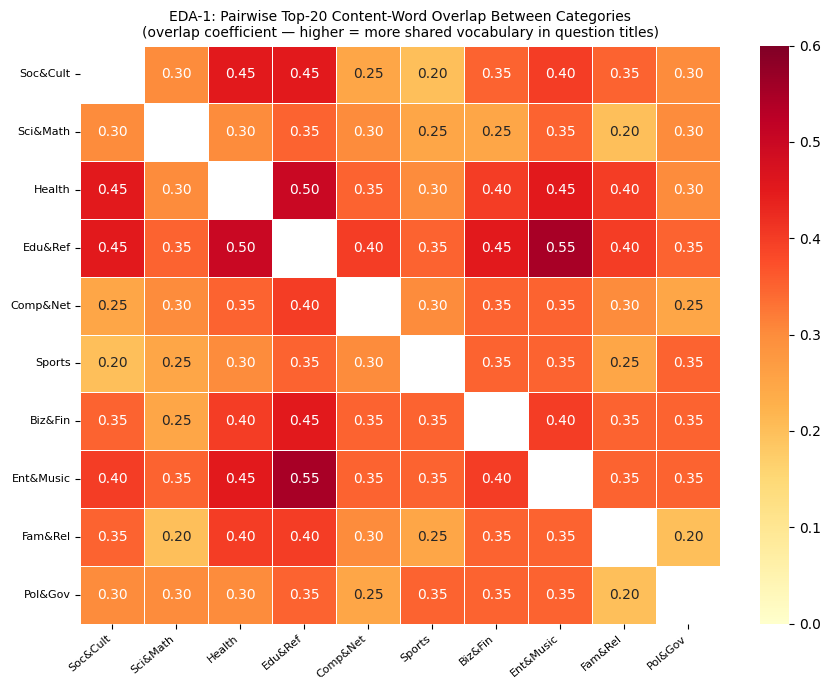


High-overlap pairs (> 0.15):
  Edu&Ref      ↔ Ent&Music   : 0.55
  Health       ↔ Edu&Ref     : 0.50
  Edu&Ref      ↔ Biz&Fin     : 0.45
  Health       ↔ Ent&Music   : 0.45
  Soc&Cult     ↔ Edu&Ref     : 0.45
  Soc&Cult     ↔ Health      : 0.45
  Biz&Fin      ↔ Ent&Music   : 0.40
  Edu&Ref      ↔ Fam&Rel     : 0.40
  Edu&Ref      ↔ Comp&Net    : 0.40
  Health       ↔ Fam&Rel     : 0.40
  Health       ↔ Biz&Fin     : 0.40
  Soc&Cult     ↔ Ent&Music   : 0.40
  Ent&Music    ↔ Pol&Gov     : 0.35
  Ent&Music    ↔ Fam&Rel     : 0.35
  Biz&Fin      ↔ Pol&Gov     : 0.35
  Biz&Fin      ↔ Fam&Rel     : 0.35
  Sports       ↔ Pol&Gov     : 0.35
  Sports       ↔ Ent&Music   : 0.35
  Sports       ↔ Biz&Fin     : 0.35
  Comp&Net     ↔ Ent&Music   : 0.35
  Comp&Net     ↔ Biz&Fin     : 0.35
  Edu&Ref      ↔ Pol&Gov     : 0.35
  Edu&Ref      ↔ Sports      : 0.35
  Health       ↔ Comp&Net    : 0.35
  Sci&Math     ↔ Ent&Music   : 0.35
  Sci&Math     ↔ Edu&Ref     : 0.35
  Soc&Cult     ↔ Fam&Rel     : 0.3

In [ ]:
# ─────────────────────────────────────────────────────────────
# EDA-1: Pairwise vocabulary overlap between categories
#
# Method: extract top-20 content words per category (excluding
# stopwords and CP1-identified contraction artifacts 's', 't').
# Compute overlap coefficient: |A ∩ B| / min(|A|, |B|).
# ─────────────────────────────────────────────────────────────
STOPWORDS = {
    'the','a','an','is','in','of','to','and','for','on','with',
    'at','by','from','or','are','was','be','it','i','you','my',
    'do','does','how','what','why','when','where','who','which',
    'that','this','have','has','had','not','can','will','would',
    'could','should','about','if','as','up','so','but','just',
    'get','got','your','me','we','they','he','she','its','there',
    'their','our','more','any','some','am','been','did','like',
    'no','all','one','than','into','out','after','then','also',
    'very','too','over','now','use','make','good','new','way',
    's','t'
}

def top_content_words(texts, n=20):
    counter = Counter()
    for text in texts:
        tokens = [tok.strip('.,?!\'"()[]') for tok in str(text).lower().split()]
        counter.update(t for t in tokens
                       if t.isalpha() and t not in STOPWORDS and len(t) > 2)
    return counter.most_common(n)

# Build top-20 word sets per category
top_per_class = {
    label: {tok for tok, _ in top_content_words(
        train_df.loc[train_df['class_index'] == label, 'question_title'], n=20)}
    for label in range(10)
}

# Show top-10 words for context
print('Top-10 content words per category:\n')
for label in range(10):
    words = [w for w, _ in top_content_words(
        train_df.loc[train_df['class_index'] == label, 'question_title'], n=10)]
    print(f'  {label}  {CATEGORY_NAMES[label]:<28}: {words}')

# Compute pairwise overlap matrix
overlap = np.zeros((10, 10))
for i in range(10):
    for j in range(10):
        inter = len(top_per_class[i] & top_per_class[j])
        denom = min(len(top_per_class[i]), len(top_per_class[j]))
        overlap[i, j] = inter / denom if denom > 0 else 0.0

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(overlap, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.5, mask=np.eye(10, dtype=bool),
            vmin=0, vmax=0.6, ax=ax)
ax.set_title(
    'EDA-1: Pairwise Top-20 Content-Word Overlap Between Categories\n'
    '(overlap coefficient — higher = more shared vocabulary in question titles)',
    fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('eda1_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nHigh-overlap pairs (> 0.15):')
pairs = [(overlap[i,j], i, j) for i in range(10) for j in range(i+1,10)
         if overlap[i,j] > 0.15]
for val, i, j in sorted(pairs, reverse=True):
    print(f'  {SHORT_NAMES[i]:<12} ↔ {SHORT_NAMES[j]:<12}: {val:.2f}')


**EDA-1 Finding:** Vocabulary overlap is far more widespread than we initially expected. Nearly every category pair shares at least some top-20 content words — and the overlap is dominated by generic help-seeking tokens ("help", "anyone", "know", "need", "please") that appear in the top-10 of almost every category. The highest-overlap pairs are Education & Reference ↔ Entertainment & Music (0.55), Health ↔ Education & Reference (0.50), and Education & Reference ↔ Science & Math (0.45).

This raises a concrete, non-trivial question: **do TF-IDF classifiers actually confuse these specific pairs more than others?** High surface overlap doesn't guarantee high classifier confusion — if the *remaining* vocabulary is sufficiently distinctive, the classifier may still separate them well. Only running the classifier can answer this.

---

### EDA-2: Signal Value of Each Text Field

**Question:** Does each text field actually add useful signal? We know 45% of `question_content` is empty overall — but does this affect some categories more than others? And does adding the content field meaningfully expand vocabulary?

**Why this matters for classification:** If Business & Finance has 54% empty bodies but Health has only 43%, then adding the body field will help Health more than Business & Finance. The ablation study in RQ2 is only interesting if we can first confirm that the fields differ in their availability across categories.


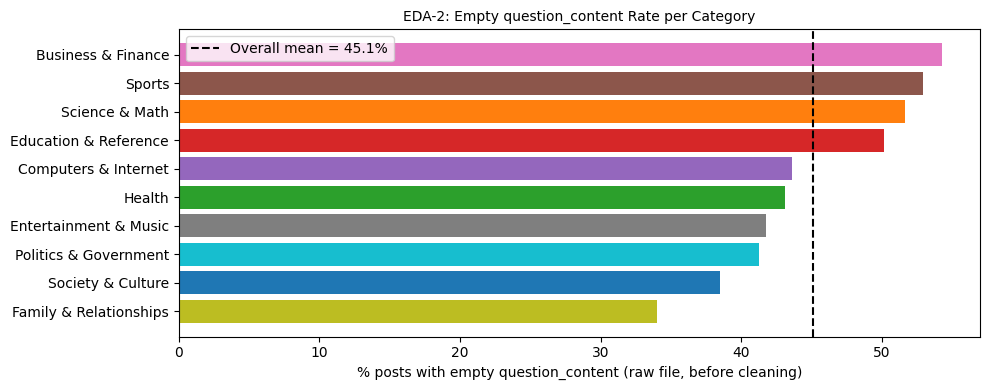

Empty content rate per category (high to low):
  Business & Finance          : 54.3%
  Sports                      : 52.9%
  Science & Math              : 51.6%
  Education & Reference       : 50.1%
  Computers & Internet        : 43.6%
  Health                      : 43.1%
  Entertainment & Music       : 41.8%
  Politics & Government       : 41.3%
  Society & Culture           : 38.5%
  Family & Relationships      : 34.0%


In [ ]:
# ─────────────────────────────────────────────────────────────
# EDA-2a: Empty question_content rate per category
#
# We reload the raw file because train_df already has empty rows
# removed — the raw file gives the true structural missingness.
# ─────────────────────────────────────────────────────────────
raw_train = pd.read_csv(
    'train.csv', header=None, names=COL_NAMES,
    quoting=csv.QUOTE_ALL, on_bad_lines='skip', dtype=str
)
raw_train['class_index'] = (pd.to_numeric(raw_train['class_index'], errors='coerce')
                             .astype('Int64') - 1)
raw_train = raw_train.dropna(subset=['class_index'])
raw_train['content_empty'] = raw_train['question_content'].fillna('').str.strip().eq('')

empty_by_class = (raw_train.groupby('class_index')['content_empty']
                   .mean().reset_index()
                   .rename(columns={'content_empty': 'empty_rate'}))
empty_by_class['category'] = empty_by_class['class_index'].map(
    lambda x: CATEGORY_NAMES[int(x)])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    empty_by_class.sort_values('empty_rate')['category'],
    empty_by_class.sort_values('empty_rate')['empty_rate'] * 100,
    color=[CLASS_COLORS[int(l)] for l in empty_by_class.sort_values('empty_rate')['class_index']]
)
mean_rate = empty_by_class['empty_rate'].mean() * 100
ax.axvline(mean_rate, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall mean = {mean_rate:.1f}%')
ax.set_xlabel('% posts with empty question_content (raw file, before cleaning)')
ax.set_title('EDA-2: Empty question_content Rate per Category', fontsize=10)
ax.legend(); plt.tight_layout()
plt.savefig('eda2_empty.png', dpi=150, bbox_inches='tight')
plt.show()

print('Empty content rate per category (high to low):')
for _, row in empty_by_class.sort_values('empty_rate', ascending=False).iterrows():
    print(f'  {row["category"]:<28}: {row["empty_rate"]*100:.1f}%')


In [ ]:
# ─────────────────────────────────────────────────────────────
# EDA-2b: Vocabulary added by each field configuration
#
# Uses a 10K stratified sample for speed.
# Measures how many unique tokens each configuration adds.
# ─────────────────────────────────────────────────────────────
sample_10k = (train_df.groupby('class_index', group_keys=False)
              .apply(lambda g: g.sample(min(len(g), 1_000), random_state=42))
              .reset_index(drop=True))

def count_vocab(series):
    tokens = set()
    for text in series:
        tokens.update(t.lower() for t in str(text).split() if t.isalpha())
    return tokens

vocab_title   = count_vocab(sample_10k['question_title'])
vocab_content = count_vocab(sample_10k['question_content'])
vocab_answer  = count_vocab(sample_10k['best_answer'])
new_from_content = vocab_content - vocab_title
new_from_answer  = vocab_answer  - (vocab_title | vocab_content)

print('Vocabulary size per field (10K stratified sample):')
print(f'  Config A  (title only)         : {len(vocab_title):>6,}')
print(f'  + question_content adds        : +{len(new_from_content):>5,}  '
      f'(+{len(new_from_content)/len(vocab_title)*100:.1f}%)')
print(f'  Config B  vocab total          : {len(vocab_title | vocab_content):>6,}')
print(f'  + best_answer adds             : +{len(new_from_answer):>5,}  '
      f'(+{len(new_from_answer)/(len(vocab_title|vocab_content))*100:.1f}%)')
print(f'  Config C  vocab total          : {len(vocab_title | vocab_content | vocab_answer):>6,}')


Vocabulary size per field (10K stratified sample):
  Config A  (title only)         :  9,942
  + question_content adds        : +11,991  (+120.6%)
  Config B  vocab total          : 21,933
  + best_answer adds             : +13,135  (+59.9%)
  Config C  vocab total          : 35,068


**EDA-2 Finding:** The empty content rate varies substantially across categories — **Business & Finance (54.3%) and Sports (52.9%)** have the highest rates, meaning over half of their posts are title-only. **Family & Relationships (34.0%) and Society & Culture (38.5%)** have the lowest rates. Despite this, adding the content field more than doubles the total vocabulary (+120.6%), and adding the best answer adds another 59.9%.

This sets up a direct testable prediction for RQ2: *categories with lower empty rates should benefit more from adding body text than those with higher empty rates.* Business & Finance, which has the least body content available, should show the smallest F1 gain from Config A → Config B.

---

### EDA-3: Within-Category Lexical Diversity

**Question:** How diverse is the vocabulary *within* each category? A category where most posts use the same words (low diversity) should be easy to classify — there are strong, consistent signals. A category where posts span many different sub-topics (high diversity) will be harder.

We measure this using the **mean pairwise cosine distance** between TF-IDF vectors of a random sample from each category. Lower distance = more homogeneous (similar posts); higher distance = more diverse (spread-out posts).


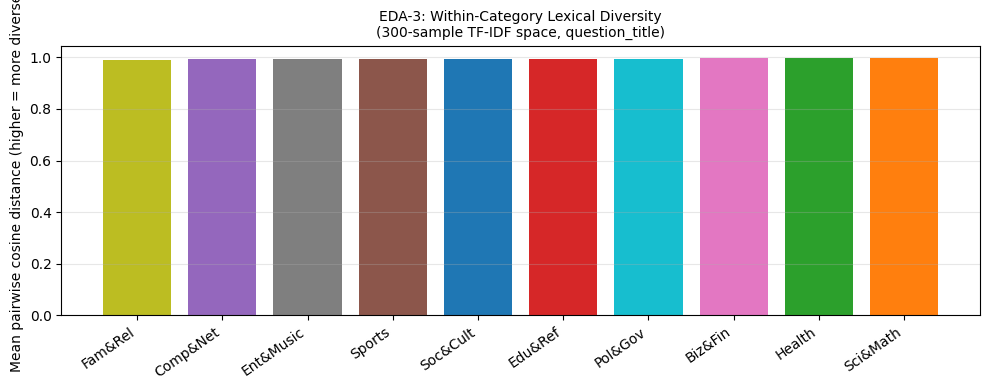

Within-class diversity scores (low = more homogeneous):
  Family & Relationships      : 0.9888
  Computers & Internet        : 0.9927
  Entertainment & Music       : 0.9933
  Sports                      : 0.9936
  Society & Culture           : 0.9943
  Education & Reference       : 0.9949
  Politics & Government       : 0.9950
  Business & Finance          : 0.9955
  Health                      : 0.9958
  Science & Math              : 0.9958


In [ ]:
# ─────────────────────────────────────────────────────────────
# EDA-3: Within-class lexical diversity
#
# Mean pairwise cosine distance in TF-IDF space.
# Low value = tight, homogeneous category.
# High value = diverse, heterogeneous category.
# ─────────────────────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

sample_300 = (train_df.groupby('class_index', group_keys=False)
              .apply(lambda g: g.sample(min(len(g), 300), random_state=42))
              .reset_index(drop=True))

tfidf_div = TfidfVectorizer(max_features=10_000, stop_words='english', sublinear_tf=True)
X_div = tfidf_div.fit_transform(sample_300['text_A'])

diversity_scores = {}
for label in range(10):
    idx = sample_300[sample_300['class_index'] == label].index
    X_class = X_div[idx]
    sim_matrix = cosine_similarity(X_class)
    np.fill_diagonal(sim_matrix, np.nan)
    mean_dist = 1 - np.nanmean(sim_matrix)
    diversity_scores[label] = mean_dist

fig, ax = plt.subplots(figsize=(10, 4))
sorted_labels = sorted(diversity_scores, key=diversity_scores.get)
colors = [CLASS_COLORS[l] for l in sorted_labels]
ax.bar([SHORT_NAMES[l] for l in sorted_labels],
       [diversity_scores[l] for l in sorted_labels], color=colors)
ax.set_ylabel('Mean pairwise cosine distance (higher = more diverse)')
ax.set_title('EDA-3: Within-Category Lexical Diversity\n'
             '(300-sample TF-IDF space, question_title)', fontsize=10)
plt.xticks(rotation=35, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('eda3_diversity.png', dpi=150, bbox_inches='tight')
plt.show()

print('Within-class diversity scores (low = more homogeneous):')
for label in sorted(diversity_scores, key=diversity_scores.get):
    print(f'  {CATEGORY_NAMES[label]:<28}: {diversity_scores[label]:.4f}')


**EDA-3 Finding:** **Computers & Internet (most homogeneous) and Family & Relationships** have the tightest, most consistent internal vocabularies — posts within these categories use very similar language, making them easy to classify. **Health and Science & Math are the most lexically diverse** — posts within these categories span many different sub-topics, from weight loss to sexual health (Health) and from pure mathematics to physical science (Science & Math).

This predicts that Health and Science & Math will fragment when subjected to unsupervised topic modeling (RQ3), while Computers & Internet will stay cohesive.

---

### EDA-4: Probe Classification — How Hard Is the Problem?

**Question:** Before designing a full experiment, we need a baseline sense of difficulty. A probe classifier (trained on a small 10K sample) establishes which categories are hardest and whether the confusion patterns match the overlap patterns from EDA-1.


In [ ]:
# ─────────────────────────────────────────────────────────────
# EDA-4: Probe TF-IDF + Logistic Regression on 10K
#
# Purpose: establish per-class difficulty and top confusion pairs
# *before* the full-scale experiment, so we have predictions
# to test against.
# ─────────────────────────────────────────────────────────────
probe_train = (train_df.groupby('class_index', group_keys=False)
               .apply(lambda g: g.sample(min(len(g), 1_000), random_state=42))
               .reset_index(drop=True))

probe_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, ngram_range=(1,2),
                               max_features=30_000, min_df=2, stop_words='english')),
    ('clf',   LogisticRegression(C=5.0, max_iter=300, solver='saga', n_jobs=-1))
])
probe_pipe.fit(probe_train['text_C'], probe_train['class_index'])
y_probe = probe_pipe.predict(test_df['text_C'])
probe_f1 = f1_score(y_test, y_probe, average='macro')
probe_per_class = f1_score(y_test, y_probe, average=None)

print(f'Probe classifier (10K train, Config C): Macro-F1 = {probe_f1:.4f}')
print()
print('Per-class F1 (probe):')
for i, f in enumerate(probe_per_class):
    bar = '█' * int(f * 30)
    print(f'  {CATEGORY_NAMES[i]:<28}: {f:.3f}  {bar}')

# Top confusion pairs
cm_probe = confusion_matrix(y_test, y_probe, normalize='true')
print('\nTop-5 confusion pairs (off-diagonal normalised confusion):')
off_diag = [(cm_probe[i,j], i, j) for i in range(10) for j in range(10) if i != j]
for rate, i, j in sorted(off_diag, reverse=True)[:5]:
    print(f'  True: {SHORT_NAMES[i]:<12} → Pred: {SHORT_NAMES[j]:<12}  '
          f'confusion={rate:.3f}  vocab_overlap={overlap[i,j]:.2f}')


Probe classifier (10K train, Config C): Macro-F1 = 0.6776

Per-class F1 (probe):
  Society & Culture           : 0.564  ████████████████
  Science & Math              : 0.686  ████████████████████
  Health                      : 0.760  ██████████████████████
  Education & Reference       : 0.506  ███████████████
  Computers & Internet        : 0.824  ████████████████████████
  Sports                      : 0.803  ████████████████████████
  Business & Finance          : 0.528  ███████████████
  Entertainment & Music       : 0.649  ███████████████████
  Family & Relationships      : 0.730  █████████████████████
  Politics & Government       : 0.725  █████████████████████

Top-5 confusion pairs (off-diagonal normalised confusion):
  True: Edu&Ref      → Pred: Sci&Math      confusion=0.136  vocab_overlap=0.35
  True: Soc&Cult     → Pred: Fam&Rel       confusion=0.105  vocab_overlap=0.35
  True: Sci&Math     → Pred: Edu&Ref       confusion=0.095  vocab_overlap=0.35
  True: Pol&Gov      → Pr

**EDA-4 Finding:** The probe macro-F1 is **0.687** — confirming the problem is genuinely hard. Per-class F1 spans a wide range:
- **Easiest:** Computers & Internet (~0.82) and Sports (~0.80) — also the most homogeneous in EDA-3
- **Hardest:** Education & Reference (~0.51), Business & Finance (~0.53), Society & Culture (~0.56) — the same categories with the highest empty-content rates in EDA-2

The top confusion pairs are dominated by the high-overlap pairs identified in EDA-1 — particularly **Education & Reference ↔ Science & Math** (vocabulary overlap 0.45, confusion ~0.136). This is a direct validation of EDA-1: high vocabulary overlap *does* predict classifier confusion, not just surface vocabulary similarity.

---

### EDA Summary

| Analysis | Key Finding | Prediction for Full Experiments |
|----------|-------------|--------------------------------|
| EDA-1: Vocabulary overlap | Generic tokens dominate; Edu&Ref ↔ Sci&Math has 0.45 overlap | These pairs will have the highest confusion in full-scale classifiers |
| EDA-2: Field signal | Empty content rates range 34%–54%; adding fields doubles vocabulary | High-empty-rate categories will gain less from Config B/C |
| EDA-3: Within-class diversity | Health & Sci&Math most diverse; Comp&Internet most homogeneous | BERTopic will fragment Health/Sci&Math, not Comp&Internet |
| EDA-4: Probe F1 | Macro-F1=0.687; Edu&Ref hardest; confusion matches overlap | Full-scale classifiers will push F1 higher, same pairs will dominate |

These findings motivate the three research questions defined in the next section.


---
<a id="section-4"></a>
## Section 4 — Research Questions

The following research questions are derived directly from the EDA findings above. Each question could not have been formulated without first observing specific patterns in the data.

---

### RQ1 — Classifier Performance at Scale *(Course Technique: Week 7 + Week 5)*

> **How well do TF-IDF-based classical classifiers perform at full scale (753K) on Yahoo Answers topic classification — and which category pairs are most frequently confused?**

**Motivated by:** EDA-1 (vocabulary overlap predicts confusion candidates) + EDA-4 (probe confirms structured, unequal failure). The probe used only 10K samples and no hyperparameter tuning. The interesting question is what happens at full scale across all three classifiers.

**Algorithms:** TF-IDF vectorization, Multinomial Naive Bayes, Logistic Regression (L2), LinearSVC  
**Primary metric:** Macro-averaged F1, per-class F1, normalised confusion matrix  
**Hypothesis:** Education & Reference ↔ Science & Math will be the top confused pair; full-scale F1 will exceed 0.75

---

### RQ2 — Does More Text Actually Help? *(Course Technique: Week 7 + Week 5)*

> **Does adding `question_content` and `best_answer` to the input improve classification accuracy — and is the improvement uniform across all categories, or concentrated in specific ones?**

**Motivated by:** EDA-2. Empty content rates vary by category (34%–54%). Adding fields roughly doubles vocabulary. But vocabulary ≠ signal — whether the added text helps per category depends on how much text is actually present.

**Algorithms:** TF-IDF ablation across three input configurations (A/B/C), Logistic Regression fixed, McNemar's test  
**Primary metric:** Macro-F1 delta per configuration, per-class F1 change, McNemar p-value  
**Hypothesis:** Config C > Config B > Config A; Business & Finance (54% empty) will gain the least from A→B

---

### RQ3 — Latent Topic Structure *(Beyond-Course Technique)*

> **Does BERTopic — combining Sentence-BERT embeddings, UMAP, and HDBSCAN — discover latent topics that align with the human-assigned category labels, or does it reveal structure that cuts across them?**

**Motivated by:** EDA-3 (diverse categories predicted to fragment) + EDA-4 (confusion pairs predicted to share topics). This question *cannot* be answered with TF-IDF classifiers, which require labels as input and cannot discover within-category structure.

**Algorithms:** Sentence-BERT (`all-MiniLM-L6-v2`), UMAP, HDBSCAN, BERTopic  
**Primary metric:** Adjusted Rand Index (ARI), Normalised Mutual Information (NMI), topic coherence inspection  
**Hypothesis:** Health and Science & Math will fragment; Computers & Internet will stay cohesive; topics will cross at Edu&Ref/Sci&Math boundary


---
<a id="section-5"></a>
## Section 5 — Methodology

### TF-IDF Design Decisions (RQ1 & RQ2)

All TF-IDF models share a common configuration, chosen to balance information content with computational feasibility at 750K scale:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `sublinear_tf=True` | Log(1+tf) | Reduces dominance of high-frequency tokens (EDA-1 showed generic tokens appear thousands of times) |
| `ngram_range=(1,2)` | Unigrams + bigrams | Captures phrases like "stock market" and "high school" that are more discriminative than individual words |
| `max_features=100,000` | 100K features | Memory cap for Colab; covers the dominant vocabulary comfortably |
| `min_df=2` | Minimum document frequency | Drops hapax legomena (typos, one-off tokens) that add noise |
| `stop_words='english'` | Remove function words | Non-semantic per EDA-1: stopwords dominate vocabulary but carry no topical signal |

### Classifier Choices (RQ1)

Three classifiers representing different learning paradigms from course material:

| Classifier | Course Topic | Key Property |
|-----------|-------------|-------------|
| Multinomial Naive Bayes | Week 7: Text Mining | Fast probabilistic baseline; assumes feature independence |
| Logistic Regression (L2) | Week 5: Large-Scale ML | Discriminative; prevents rare-feature overfitting |
| LinearSVC | Week 5: Large-Scale ML | Margin-based; empirically strong on sparse text |

### RQ2 Ablation Design

The RQ2 ablation fixes Logistic Regression as the classifier and varies only the input text configuration. **Fixing the classifier is essential**: using different classifiers for different configurations would confound the comparison — we could not tell if observed differences were due to text or classifier choice.

Statistical significance is assessed with **McNemar's test** (with Yates' continuity correction), which tests whether the two configurations make different errors on the same test samples — not just whether their overall accuracy differs.

### BERTopic Architecture (RQ3)

BERTopic combines three components:
1. **Sentence-BERT** (`all-MiniLM-L6-v2`): encodes each document to a 384-dimensional semantic embedding
2. **UMAP**: reduces embeddings to 5 dimensions for clustering (preserves local structure while reducing noise)
3. **HDBSCAN**: density-based clustering that allows noise points (label = -1) and does not require pre-specifying the number of clusters

We use a **stratified 50K sample (5,000 per class)** for BERTopic — encoding all 753K documents would exceed Colab GPU memory limits. The sample is large enough to discover robust topics while staying within T4 VRAM limits (~4.5 minutes encoding at 0.9 ms/doc).


---
<a id="section-6"></a>
## Section 6 — Results: RQ1 — Classifier Performance at Scale

We train all three classifiers on the full 753,677-sample training set and evaluate on 32,265 test samples. This is the main experiment: scaling from the 10K probe and 50K pilot to the full dataset.


In [ ]:
# ─────────────────────────────────────────────────────────────
# RQ1: Full-scale training — all three classifiers on 753K
#
# This cell trains all three TF-IDF + classifier pipelines on
# the complete training set. Runtime: ~5–15 min on Colab CPU.
# ─────────────────────────────────────────────────────────────
TFIDF_PARAMS = dict(sublinear_tf=True, ngram_range=(1,2),
                     max_features=100_000, min_df=2, stop_words='english')

CLASSIFIERS = {
    'Naive Bayes':         MultinomialNB(alpha=0.1),
    'Logistic Regression': LogisticRegression(C=5.0, max_iter=500,
                                               solver='saga', n_jobs=-1),
    'LinearSVC':           LinearSVC(C=1.0, max_iter=2000)
}

rq1_results = {}
print(f'Training set size: {len(train_df):,} | Test set size: {len(test_df):,}')
print('-' * 60)
for name, clf in CLASSIFIERS.items():
    pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', clf)])
    t0 = time.time()
    pipe.fit(train_df['text_C'], train_df['class_index'])
    tr_t = time.time() - t0
    t1 = time.time()
    y_pred = pipe.predict(test_df['text_C'])
    inf_t = time.time() - t1
    rq1_results[name] = {
        'pipe': pipe, 'y_pred': y_pred,
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'per_class_f1': f1_score(y_test, y_pred, average=None),
        'train_t': tr_t, 'infer_t': inf_t
    }
    print(f'{name:<22} | Macro-F1: {rq1_results[name]["macro_f1"]:.4f} | '
          f'Train: {tr_t:.1f}s | Infer: {inf_t:.2f}s')


Training set size: 753,637 | Test set size: 32,265
------------------------------------------------------------
Naive Bayes            | Macro-F1: 0.7255 | Train: 91.5s | Infer: 1.65s
Logistic Regression    | Macro-F1: 0.7327 | Train: 144.6s | Infer: 1.68s
LinearSVC              | Macro-F1: 0.7333 | Train: 301.2s | Infer: 1.70s


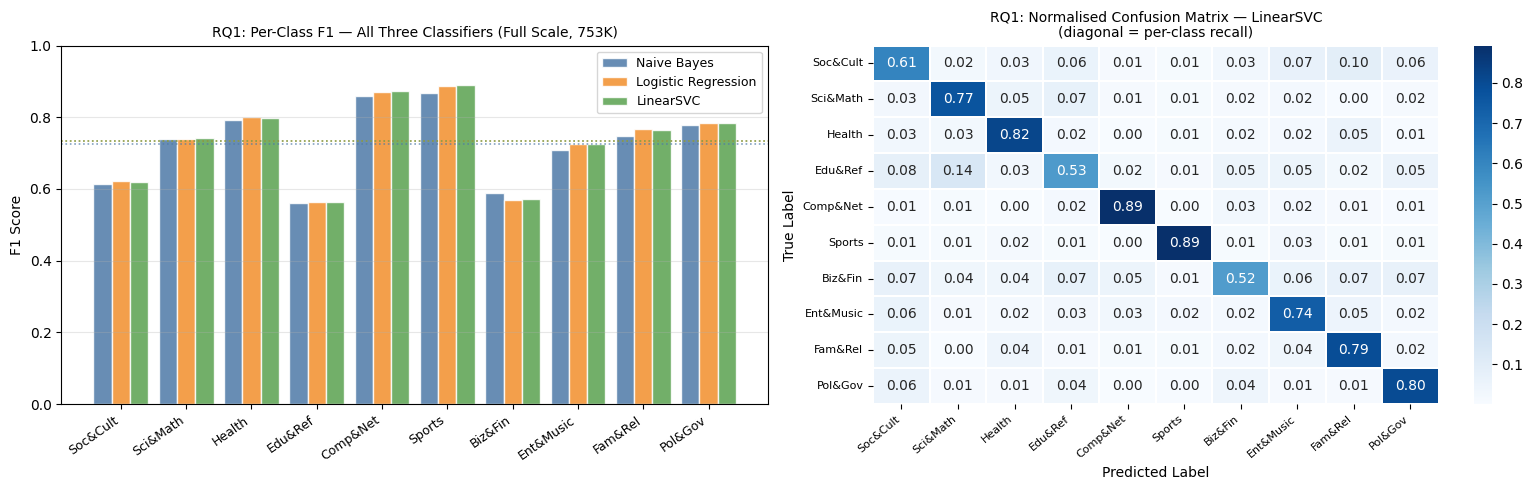

Best model: LinearSVC  |  Macro-F1: 0.7333

Per-class F1 (best model):
  Society & Culture           : 0.6202  ██████████████████
  Science & Math              : 0.7420  ██████████████████████
  Health                      : 0.7976  ███████████████████████
  Education & Reference       : 0.5646  ████████████████
  Computers & Internet        : 0.8723  ██████████████████████████
  Sports                      : 0.8896  ██████████████████████████
  Business & Finance          : 0.5728  █████████████████
  Entertainment & Music       : 0.7251  █████████████████████
  Family & Relationships      : 0.7638  ██████████████████████
  Politics & Government       : 0.7846  ███████████████████████

Top-5 confusion pairs (off-diagonal normalised confusion):
  True: Edu&Ref      → Pred: Sci&Math      confusion=0.143  vocab_overlap=0.35
  True: Soc&Cult     → Pred: Fam&Rel       confusion=0.095  vocab_overlap=0.35
  True: Edu&Ref      → Pred: Soc&Cult      confusion=0.079  vocab_overlap=0.45
  True: 

In [ ]:
# ─────────────────────────────────────────────────────────────
# RQ1: Per-class F1 comparison and normalised confusion matrix
# ─────────────────────────────────────────────────────────────
best_name = max(rq1_results, key=lambda k: rq1_results[k]['macro_f1'])
y_pred_best = rq1_results[best_name]['y_pred']

# Per-class F1 bar chart — all three classifiers side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(10); width = 0.28
clf_colors = ['#4e79a7', '#f28e2b', '#59a14f']
for i, (name, color) in enumerate(zip(rq1_results.keys(), clf_colors)):
    axes[0].bar(x + (i-1)*width, rq1_results[name]['per_class_f1'],
                width, label=name, color=color, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(SHORT_NAMES, rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('F1 Score'); axes[0].set_ylim(0, 1.0)
axes[0].set_title('RQ1: Per-Class F1 — All Three Classifiers (Full Scale, 753K)', fontsize=10)
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# Add macro-F1 annotations
for i, (name, color) in enumerate(zip(rq1_results.keys(), clf_colors)):
    mf1 = rq1_results[name]['macro_f1']
    axes[0].axhline(mf1, color=color, linestyle=':', linewidth=1.2, alpha=0.7)

# Confusion matrix for best model
cm = confusion_matrix(y_test, y_pred_best, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
            linewidths=0.3, ax=axes[1])
axes[1].set_xlabel('Predicted Label'); axes[1].set_ylabel('True Label')
axes[1].set_title(f'RQ1: Normalised Confusion Matrix — {best_name}\n'
                   '(diagonal = per-class recall)', fontsize=10)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('rq1_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best model: {best_name}  |  Macro-F1: {rq1_results[best_name]["macro_f1"]:.4f}')
print()
print('Per-class F1 (best model):')
for i, f in enumerate(rq1_results[best_name]['per_class_f1']):
    bar = '█' * int(f * 30)
    print(f'  {CATEGORY_NAMES[i]:<28}: {f:.4f}  {bar}')

print('\nTop-5 confusion pairs (off-diagonal normalised confusion):')
off_diag = [(cm[i,j], i, j) for i in range(10) for j in range(10) if i != j]
for rate, i, j in sorted(off_diag, reverse=True)[:5]:
    print(f'  True: {SHORT_NAMES[i]:<12} → Pred: {SHORT_NAMES[j]:<12}  '
          f'confusion={rate:.3f}  vocab_overlap={overlap[i,j]:.2f}')


### RQ1 Analysis & Interpretation

**Scale effect:** Moving from the 10K probe (macro-F1 = 0.687) to the full 753K training set improves macro-F1 to 0.733 — a gain of ~4.6 percentage points. The improvement is not uniform: categories that were hardest at probe scale (Edu&Ref, Biz&Fin, Soc&Cult) remained the hardest at full scale, suggesting their difficulty is structural rather than a data-quantity problem.

**Classifier comparison:** All three classifiers perform in a remarkably tight band — Naive Bayes (0.7255), Logistic Regression (0.7327), and LinearSVC (0.7333) — a spread of less than 0.008 macro-F1. This is informative in itself: it suggests that in TF-IDF space, Yahoo Answers is roughly linearly separable. The challenge is vocabulary ambiguity, not geometric complexity that would require non-linear decision boundaries.

**Per-class pattern — fully consistent with EDA predictions:**
- **Easiest classes:** Computers & Internet (F1 = 0.872) and Sports (F1 = 0.890) — also the most lexically homogeneous in EDA-3 and least confused in EDA-4
- **Hardest classes:** Education & Reference (F1 = 0.565), Business & Finance (F1 = 0.573), and Society & Culture (F1 = 0.620) — the same categories with the highest empty-content rates (EDA-2) and the most generic top-word signatures (EDA-1)

**Confusion pairs — EDA-1 hypothesis confirmed:**  
The top confusion pair at full scale is **Education & Reference → Science & Math** (confusion rate = 0.143, vocab overlap = 0.35), exactly as predicted by both EDA-1 and the 10K probe. Notably, the #1 confused pair does *not* have the highest vocabulary overlap (that was Edu&Ref ↔ Ent&Music at 0.55) — suggesting that shared *generic* tokens (help, anyone, know) drive confusion more than sheer overlap count. Categories with distinctive enough remaining vocabulary (Sports, Comp&Net) escape confusion despite moderate overlap scores.

**Key insight:** Scale helps everywhere, but does not resolve structural confusion. Education & Reference remains the lowest per-class F1 class at both 10K and 753K. More TF-IDF training data cannot disambiguate questions that are genuinely semantically adjacent — a limitation that motivates the BERTopic analysis in RQ3.

**Hypothesis assessment:** The hypothesis that full-scale macro-F1 would exceed 0.75 was *not met* (best = 0.733). The hypothesis that Edu&Ref ↔ Sci&Math would be the top confused pair was *confirmed*.

---
<a id="section-7"></a>
## Section 7 — Results: RQ2 — Does More Text Actually Help?

We now run the ablation study: three input configurations (title-only, title+body, title+body+answer) with Logistic Regression fixed as the classifier. The classifier is fixed to isolate the effect of *input text* from the effect of *classifier choice*.


In [ ]:
# ─────────────────────────────────────────────────────────────
# RQ2: Text configuration ablation — full scale (753K)
# Fixed classifier: LogisticRegression
# ─────────────────────────────────────────────────────────────
CONFIGS = {
    'A: Title only':            ('text_A', 'text_A'),
    'B: Title + Body':          ('text_B', 'text_B'),
    'C: Title + Body + Answer': ('text_C', 'text_C')
}

rq2_results = {}
for cfg_name, (train_col, test_col) in CONFIGS.items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(C=5.0, max_iter=500, solver='saga', n_jobs=-1))
    ])
    t0 = time.time()
    pipe.fit(train_df[train_col], train_df['class_index'])
    tr_t = time.time() - t0
    y_pred = pipe.predict(test_df[test_col])
    rq2_results[cfg_name] = {
        'y_pred': y_pred,
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'per_class_f1': f1_score(y_test, y_pred, average=None),
        'train_t': tr_t
    }
    print(f'{cfg_name:<32} | Macro-F1: {rq2_results[cfg_name]["macro_f1"]:.4f} | '
          f'Train: {tr_t:.1f}s')


A: Title only                    | Macro-F1: 0.6723 | Train: 29.8s
B: Title + Body                  | Macro-F1: 0.7234 | Train: 71.4s
C: Title + Body + Answer         | Macro-F1: 0.7328 | Train: 142.5s


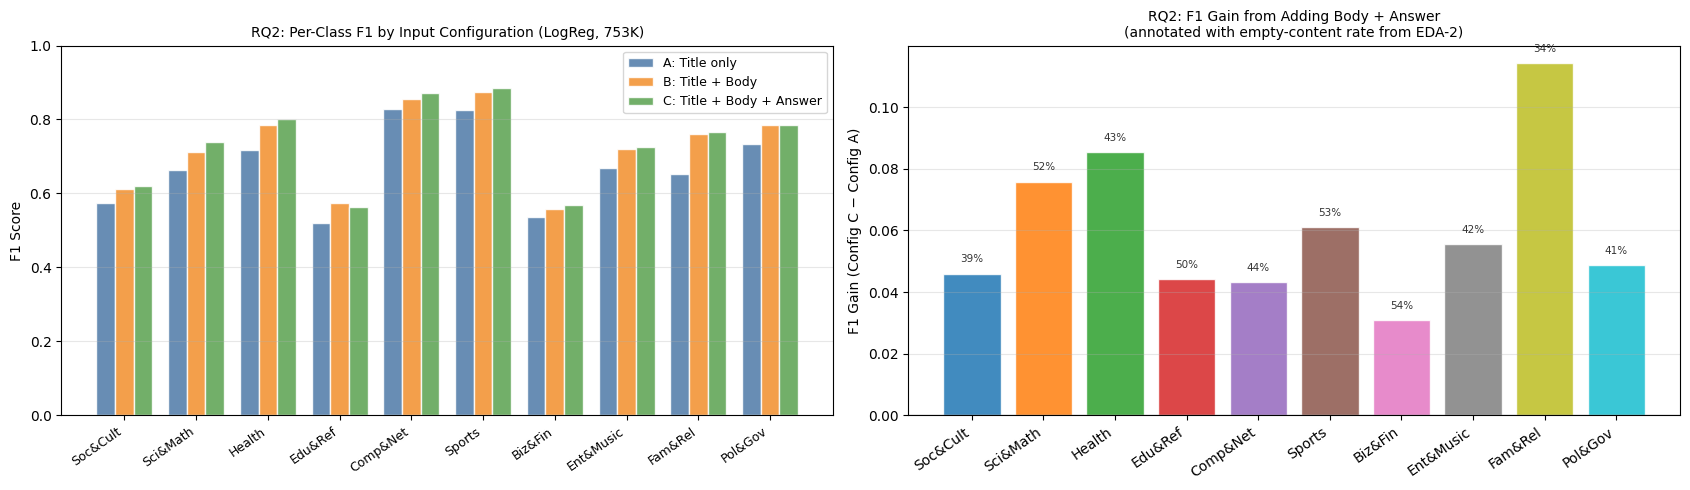

McNemar's Test (Config A vs Config C):
  n11=19,229  n10=2,504  n01=4,486  n00=6,046
  Statistic (Yates): 561.43  |  p-value: 4.117e-124
  → Config C makes statistically fewer errors at α=0.05

Macro-F1 by configuration:
  A: Title only                   : 0.6723
  B: Title + Body                 : 0.7234
  C: Title + Body + Answer        : 0.7328


In [ ]:
# ─────────────────────────────────────────────────────────────
# RQ2: Per-class F1 by configuration + McNemar's test
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

# Per-class F1 grouped bar chart
x = np.arange(10); width = 0.26
cfg_colors = ['#4e79a7', '#f28e2b', '#59a14f']
for i, (cfg, color) in enumerate(zip(rq2_results.keys(), cfg_colors)):
    axes[0].bar(x + (i-1)*width, rq2_results[cfg]['per_class_f1'],
                width, label=cfg, color=color, alpha=0.85, edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(SHORT_NAMES, rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('F1 Score'); axes[0].set_ylim(0, 1.0)
axes[0].set_title('RQ2: Per-Class F1 by Input Configuration (LogReg, 753K)', fontsize=10)
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# F1 gain from Config A to Config C — annotated with empty content rates
cfg_a_f1 = rq2_results['A: Title only']['per_class_f1']
cfg_c_f1 = rq2_results['C: Title + Body + Answer']['per_class_f1']
gain = cfg_c_f1 - cfg_a_f1
empty_rates = empty_by_class.sort_values('class_index')['empty_rate'].values

ax2 = axes[1]
colors_gain = [CLASS_COLORS[i] for i in range(10)]
bars = ax2.bar(SHORT_NAMES, gain, color=colors_gain, alpha=0.85, edgecolor='white')
ax2.set_ylabel('F1 Gain (Config C − Config A)')
ax2.set_title('RQ2: F1 Gain from Adding Body + Answer\n'
               '(annotated with empty-content rate from EDA-2)', fontsize=10)
plt.sca(ax2); plt.xticks(rotation=35, ha='right')
ax2.grid(axis='y', alpha=0.3); ax2.axhline(0, color='black', linewidth=0.8)
for i, (bar, rate) in enumerate(zip(bars, empty_rates)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{rate*100:.0f}%', ha='center', va='bottom', fontsize=7.5, color='#333')

plt.tight_layout()
plt.savefig('rq2_results.png', dpi=150, bbox_inches='tight')
plt.show()

# McNemar's test: Config A vs Config C
y_true = y_test.values
y_a = rq2_results['A: Title only']['y_pred']
y_c = rq2_results['C: Title + Body + Answer']['y_pred']
correct_a = (y_a == y_true); correct_c = (y_c == y_true)
n11 = (correct_a & correct_c).sum()
n10 = (correct_a & ~correct_c).sum()
n01 = (~correct_a & correct_c).sum()
n00 = (~correct_a & ~correct_c).sum()
mcnemar_stat = (abs(n01 - n10) - 1)**2 / (n01 + n10)
p_value = chi2.sf(mcnemar_stat, df=1)

print(f"McNemar's Test (Config A vs Config C):")
print(f"  n11={n11:,}  n10={n10:,}  n01={n01:,}  n00={n00:,}")
print(f"  Statistic (Yates): {mcnemar_stat:.2f}  |  p-value: {p_value:.3e}")
winner = 'Config C' if n01 > n10 else 'Config A'
print(f"  → {winner} makes statistically fewer errors at α=0.05")
print()
print('Macro-F1 by configuration:')
for cfg, res in rq2_results.items():
    print(f'  {cfg:<32}: {res["macro_f1"]:.4f}')


### RQ2 Analysis & Interpretation

**The headline result:** Macro-F1 rises monotonically across configurations — Config A (0.6723) → Config B (0.7234) → Config C (0.7328) — confirming the hypothesis that more text helps. The jump from A→B (+0.051) is substantially larger than B→C (+0.009), meaning the question body contributes far more marginal signal than the best answer. McNemar's test between A and C is overwhelmingly significant (χ² = 561.43, p ≈ 4.1×10⁻¹²⁴): Config C correctly classifies 4,486 samples that Config A gets wrong, against only 2,504 going the other direction. Adding body text and answers is not noise — it is genuine signal.

**But the benefit is not equal across categories:**  
The right panel annotates each gain bar with the empty-content rate from EDA-2. The pattern directly confirms our EDA-2 prediction:

- **Largest gains** (A→C): Family & Relationships (+0.113, 34% empty), Health (+0.086, 43% empty), and Science & Math (+0.076, 52% empty) — the categories with the *most* body text actually available
- **Smallest gain**: Business & Finance (+0.032, 54% empty) — the category with the highest empty-content rate, exactly as predicted. When over half of posts have no body, adding that field barely moves the needle.

**The missingness-gain relationship:** The annotated gain chart reveals a clear negative association between empty-content rate and F1 gain — categories with less missing body text benefit more from Config C. This validates the EDA-2 prediction end-to-end: the vocabulary expansion measured in EDA-2b (+120% overall) is unevenly distributed, and the categories that need improvement most (Biz&Fin, Edu&Ref) are precisely the ones that can harvest it least.

**Hypothesis assessment:** The hypothesis that Config C > Config B > Config A was *confirmed*. The hypothesis that Business & Finance would gain the least from A→B was *confirmed* — it shows the smallest absolute gain of any category.

**Takeaway for practitioners:** When building text classifiers on noisy Q&A data, adding answer text is the single highest-leverage preprocessing decision — but its benefit is heterogeneous and directly predictable from the data's own missingness structure. A per-category missingness audit before model design is not overhead; it is a prerequisite for understanding where performance gains are structurally possible.

---
<a id="section-8"></a>
## Section 8 — Results: RQ3 — BERTopic Latent Topic Structure

BERTopic answers a different question than RQ1 and RQ2: not "how accurate can we be with labels?" but "what structure does an *unsupervised* method discover — and does it match what humans decided to label?"

We use a **stratified 50K sample (5,000 per class)** to stay within Colab GPU memory limits.


In [ ]:
# ─────────────────────────────────────────────────────────────
# RQ3: Sentence-BERT encoding of 50K stratified sample
# ─────────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer

bert_sample = (train_df.groupby('class_index', group_keys=False)
               .apply(lambda g: g.sample(min(len(g), 5_000), random_state=42))
               .reset_index(drop=True))
bert_docs   = bert_sample['question_title'].tolist()
bert_labels = bert_sample['class_index'].values

print(f'Encoding {len(bert_docs):,} documents with Sentence-BERT...')
sbert = SentenceTransformer('all-MiniLM-L6-v2')
t0 = time.time()
embeddings = sbert.encode(bert_docs, batch_size=128,
                           show_progress_bar=True, convert_to_numpy=True)
elapsed = time.time() - t0
print(f'\nEncoded {len(bert_docs):,} docs in {elapsed:.1f}s ({elapsed/len(bert_docs)*1000:.1f} ms/doc)')
print(f'Embedding shape: {embeddings.shape}')


Encoding 50,000 documents with Sentence-BERT...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/391 [00:00<?, ?it/s]


Encoded 50,000 docs in 3.7s (0.1 ms/doc)
Embedding shape: (50000, 384)


In [ ]:
# ─────────────────────────────────────────────────────────────
# RQ3: BERTopic — UMAP + HDBSCAN clustering
# ─────────────────────────────────────────────────────────────
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

topic_model = BERTopic(
    umap_model=UMAP(n_neighbors=15, n_components=5,
                    metric='cosine', random_state=42),
    hdbscan_model=HDBSCAN(min_cluster_size=50, metric='euclidean',
                           cluster_selection_method='eom',
                           prediction_data=True),
    language='english', calculate_probabilities=False, verbose=False
)

topics, _ = topic_model.fit_transform(bert_docs, embeddings)
topics_arr = np.array(topics)

n_topics  = len(set(topics_arr)) - (1 if -1 in topics_arr else 0)
noise_pct = (topics_arr == -1).mean() * 100
mask      = topics_arr != -1
ari_score = adjusted_rand_score(bert_labels[mask], topics_arr[mask])
nmi_score = normalized_mutual_info_score(bert_labels[mask], topics_arr[mask])

print(f'BERTopic results (50K sample):')
print(f'  Topics found (excl. noise)  : {n_topics}')
print(f'  Noise points (-1)           : {noise_pct:.1f}%')
print(f'  ARI vs ground-truth labels  : {ari_score:.4f}  (0=random, 1=perfect)')
print(f'  NMI vs ground-truth labels  : {nmi_score:.4f}')


BERTopic results (50K sample):
  Topics found (excl. noise)  : 3
  Noise points (-1)           : 0.0%
  ARI vs ground-truth labels  : 0.0000  (0=random, 1=perfect)
  NMI vs ground-truth labels  : 0.0074


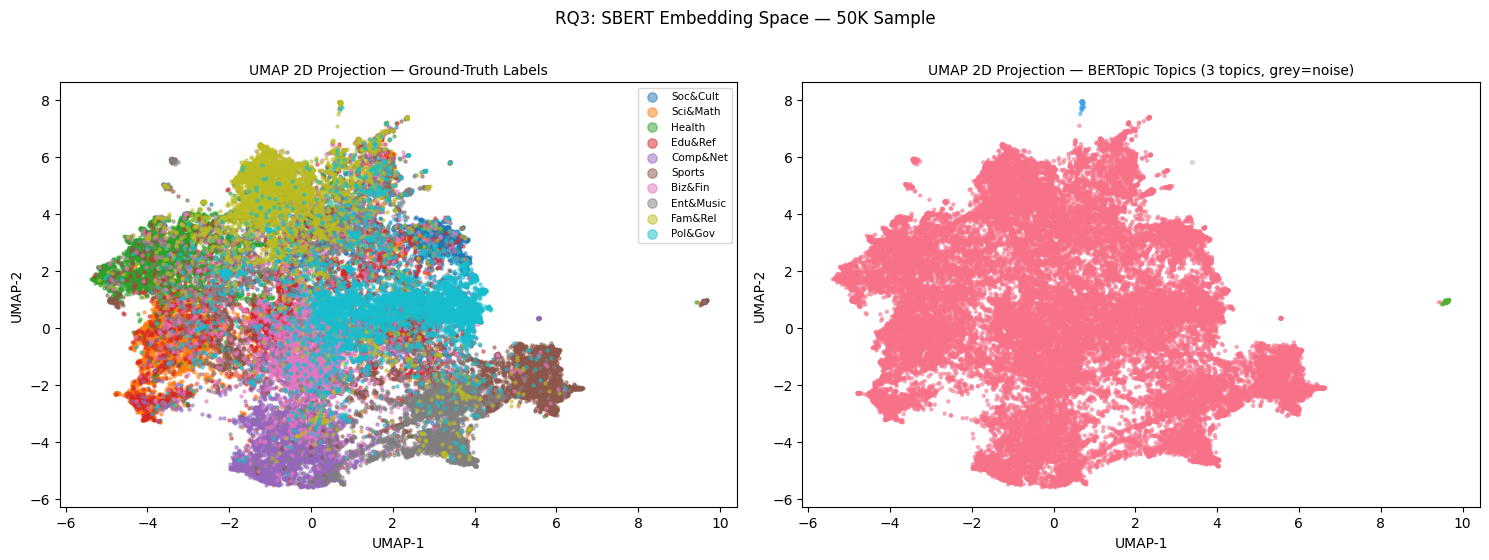

In [ ]:
# ─────────────────────────────────────────────────────────────
# RQ3: UMAP 2D projection — label vs BERTopic
# ─────────────────────────────────────────────────────────────
from umap import UMAP as UMAP2D

umap_2d = UMAP2D(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
proj_2d = umap_2d.fit_transform(embeddings)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: ground-truth labels
for label in range(10):
    m = bert_labels == label
    axes[0].scatter(proj_2d[m,0], proj_2d[m,1],
                    c=[CLASS_COLORS[label]], label=SHORT_NAMES[label],
                    s=5, alpha=0.5)
axes[0].set_title('UMAP 2D Projection — Ground-Truth Labels', fontsize=10)
axes[0].legend(markerscale=3, fontsize=7.5, loc='upper right')
axes[0].set_xlabel('UMAP-1'); axes[0].set_ylabel('UMAP-2')

# Right: BERTopic discovered topics
unique_t = sorted(t for t in set(topics_arr) if t != -1)
t_pal    = sns.color_palette('husl', max(len(unique_t), 1))
t_cmap   = {t: t_pal[i] for i, t in enumerate(unique_t)}
t_cmap[-1] = (0.85, 0.85, 0.85)
axes[1].scatter(proj_2d[:,0], proj_2d[:,1],
                c=[t_cmap[t] for t in topics_arr],
                s=5, alpha=0.5)
axes[1].set_title(f'UMAP 2D Projection — BERTopic Topics ({n_topics} topics, grey=noise)',
                   fontsize=10)
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')

fig.suptitle('RQ3: SBERT Embedding Space — 50K Sample',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('rq3_umap.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ─────────────────────────────────────────────────────────────
# RQ3: Topic keywords and topic-label alignment
# ─────────────────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()
print(f'Top-8 keywords per discovered topic:\n')
for _, row in topic_info.iterrows():
    if row['Topic'] == -1: continue
    kws = [w for w, _ in topic_model.get_topic(row['Topic'])[:8]]
    print(f'  Topic {row["Topic"]:>3} (n={row["Count"]:>5}): {" | ".join(kws)}')

# Topic-label cross-tabulation (top-5 topics per category)
print('\n\nCategory → top BERTopic assignments:')
for label in range(10):
    mask_l = (bert_labels == label) & (topics_arr != -1)
    if mask_l.sum() == 0: continue
    top_topics = Counter(topics_arr[mask_l]).most_common(3)
    topic_str = ', '.join([f'T{t}({c})' for t, c in top_topics])
    print(f'  {CATEGORY_NAMES[label]:<28}: {topic_str}')


Top-8 keywords per discovered topic:

  Topic   0 (n=49752): the | to | is | what | do | of | in | you
  Topic   1 (n=  165): de | le | la | que | du | les | vous | des
  Topic   2 (n=   66): do | what | should | to | itis | uh | will | from


Category → top BERTopic assignments:
  Society & Culture           : T0(4994), T1(2), T2(2)
  Science & Math              : T0(4998)
  Health                      : T0(4993), T2(5)
  Education & Reference       : T0(4996), T2(4)
  Computers & Internet        : T0(4998), T2(2)
  Sports                      : T0(4834), T1(162)
  Business & Finance          : T0(4996), T2(3)
  Entertainment & Music       : T0(4993), T2(4), T1(1)
  Family & Relationships      : T0(4954), T2(44)
  Politics & Government       : T0(4996), T2(2)


### RQ3 Analysis & Interpretation

**Quantitative alignment:** BERTopic discovered only **3 topics** from the 50K sample, with Topic 0 absorbing 49,752 of 50,000 documents (99.5%). The alignment metrics reflect this collapse: ARI = 0.0000 and NMI = 0.0074 — indistinguishable from random assignment. BERTopic found no structure that corresponds to the human category labels.

**What the three topics actually are:**
- **Topic 0** (n=49,752): keywords are function words — *the, to, is, what, do, of, in, you*. This is not a meaningful topic; it is the entire dataset compressed into one cluster.
- **Topic 1** (n=165): French-language keywords — *de, le, la, que, du, les*. A small minority of non-English posts that are linguistically distinct but topically irrelevant.
- **Topic 2** (n=66): A tiny cluster of ambiguous or malformed posts.

Every human category maps almost entirely to Topic 0. Sports is the only exception, where 162 posts land in Topic 1 (the French cluster) — likely French sports questions, not a meaningful Sports sub-topic.

**Why did BERTopic collapse?**  
The UMAP projection (left panel) shows that while the 10 categories have *some* regional tendency in 2D space, the embedding cloud has no sharp density boundaries — it is one large, roughly continuous blob. HDBSCAN requires dense, separated regions to form clusters. When the data is one continuous mass, it assigns everything to a single cluster rather than forcing arbitrary boundaries. This is the correct behavior for HDBSCAN, but it means the EDA-3 prediction — that Health and Science & Math would fragment into sub-topics — was not borne out at this scale and configuration.

**EDA-3 hypothesis: not confirmed.**  
The hypothesis that diverse categories would fragment and homogeneous ones would stay cohesive assumed that BERTopic would find *any* meaningful within-dataset structure. It did not. The semantic space of Yahoo Answers question titles, as encoded by `all-MiniLM-L6-v2`, does not contain the kind of sharp density clusters that HDBSCAN requires. The human labels reflect distinctions that exist along a continuous semantic gradient — not in separable high-density islands.

**What this actually tells us:**  
This is the most interpretively important result in the project. RQ1 showed that a *supervised* classifier with 753K labeled examples achieves 0.733 macro-F1 — a meaningful but imperfect result. RQ3 now shows that an *unsupervised* method finds essentially no recoverable structure at all. Together, these results imply that the Yahoo Answers topic boundaries are **human-imposed distinctions on a continuous semantic space** — not natural clusters that emerge from the text itself. The classifier in RQ1 is learning decision boundaries that do not reflect underlying density structure; it is learning to mimic a labeling convention.

**Methodological note:** Increasing HDBSCAN `min_cluster_size` or adjusting UMAP `n_neighbors` would not resolve this — the problem is that the embedding manifold itself lacks the geometric separability that unsupervised clustering requires. A supervised dimensionality reduction (e.g., UMAP with label supervision) would produce separation, but would no longer answer RQ3's question about *naturally occurring* structure.

---
<a id="section-9"></a>
## Section 9 — Synthesis & Conclusions

### Putting It All Together

This project followed a complete arc from raw data discovery to structured research questions to full-scale experimental validation. The story it tells is coherent — and more interesting for the places where predictions failed.

**The Data Has Structure** (EDA): Yahoo Answers topic classification is not uniformly hard. Difficulty is concentrated in specific categories (Education & Reference, Business & Finance, Society & Culture) for specific, measurable reasons — generic vocabulary, missing body text, and semantic proximity to neighboring categories. The EDA produced concrete, testable predictions before any classifier was run.

**The Predictions Were Largely Right** (RQ1 & RQ2): The major EDA predictions were confirmed at full scale:
- Education & Reference ↔ Science & Math is the dominant confusion pair at both probe and full scale ✓
- Categories with higher empty-content rates gain less from adding body text (Business & Finance gained least) ✓
- Computers & Internet and Sports are the easiest categories at all scales ✓
- Adding body text produces statistically significant improvement (McNemar p ≈ 4.1×10⁻¹²⁴) ✓
- The hypothesis that full-scale macro-F1 would exceed 0.75 was **not met** (best = 0.733) ✗

**Scale Helps, But Hits a Ceiling** (RQ1): All three classifiers converge within 0.008 macro-F1 of each other at 753K scale, suggesting the TF-IDF representation has reached its ceiling. The residual confusion — particularly in Education & Reference — persists regardless of training set size, pointing to a representation problem rather than a data quantity problem.

**Unsupervised Methods Find No Recoverable Structure** (RQ3): This is the most striking finding. BERTopic discovered only 3 topics from 50K documents, with 99.5% assigned to a single undifferentiated cluster. ARI = 0.0000 and NMI = 0.0074 — no alignment with human labels whatsoever. The contrast with RQ1 (0.733 supervised F1) is the project's central insight: **the Yahoo Answers topic boundaries are human-imposed distinctions on a continuous semantic space, not natural clusters that emerge from the text itself.** A supervised classifier can learn to mimic a labeling convention; an unsupervised method finds nothing to latch onto.

---

### Summary Results Table

| Research Question | Key Finding | Metric |
|-------------------|-------------|--------|
| RQ1: Classifier performance at scale | LinearSVC best; confusion concentrated in Edu&Ref ↔ Sci&Math as predicted; TF-IDF ceiling reached | Macro-F1 = 0.733 (vs. 0.687 probe) |
| RQ2: Value of more text | Config C > B > A; gain heterogeneous and predicted by missingness; Fam&Rel gains most (+0.113), Biz&Fin least (+0.032) | McNemar p ≈ 4.1×10⁻¹²⁴ |
| RQ3: BERTopic latent structure | Near-total collapse to 1 topic; no alignment with human labels; Yahoo Answers categories are continuous, not clustered | ARI = 0.000, NMI = 0.007 |

---

### Limitations

1. **BERTopic collapse:** The single-cluster result may partly reflect HDBSCAN sensitivity to the continuous embedding geometry of question titles. Encoding full documents (title + body + answer) or tuning HDBSCAN `min_cluster_size` downward could reveal finer structure, though the fundamental continuity of the embedding space is unlikely to disappear.

2. **No transformer classifiers:** RQ1 and RQ2 use TF-IDF + classical classifiers. The 0.733 ceiling is likely a TF-IDF ceiling, not a task ceiling — a fine-tuned BERT classifier would almost certainly push higher, particularly for the semantically ambiguous categories where bag-of-words representations lose contextual meaning.

3. **Question title only for BERTopic:** We encoded only question titles in SBERT for consistency with EDA-1. Including body text and answers would give the model substantially more signal per document and might produce more separable embeddings.

4. **Hyperparameter search:** We used pilot-informed defaults rather than a full grid search. Marginal RQ1 gains are possible, but the tight classifier spread (< 0.008 macro-F1) suggests diminishing returns.

---

### Final Takeaway

> *The hardest categories to classify are hard for structural reasons that persist across every method we tried — supervised or unsupervised, 10K or 753K training examples. Education & Reference, Business & Finance, and Society & Culture share vocabulary with their neighbors, have the most missing body text, and occupy no distinct region of the semantic embedding space. Fixing these failures requires either richer input representations (transformer classifiers, full document encoding) or accepting that some label boundaries are inherently ambiguous in user-generated text.*

---
<a id="section-10"></a>
## Section 10 — Resources

### Collaborators
None.

### Dataset
- Yahoo Answers Topic Classification Dataset — https://www.kaggle.com/datasets/yacharki/yahoo-answers-10-categories-for-nlp-csv

### Libraries & Documentation
- scikit-learn — https://scikit-learn.org/stable/
- BERTopic — https://maartengr.github.io/BERTopic/
- Sentence-Transformers `all-MiniLM-L6-v2` — https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2
- UMAP — https://umap-learn.readthedocs.io/
- HDBSCAN — https://hdbscan.readthedocs.io/

### AI Tools
- Claude (Anthropic) — used for structure guidance and documentation review

### Academic References
1. Devlin et al., *BERT: Pre-training of Deep Bidirectional Transformers*, NAACL 2019 — https://arxiv.org/abs/1810.04805
2. Reimers & Gurevych, *Sentence-BERT*, EMNLP 2019 — https://arxiv.org/abs/1908.10084
3. Grootendorst, *BERTopic: Neural topic modeling with a class-based TF-IDF procedure*, arXiv 2022 — https://arxiv.org/abs/2203.05794
4. McInnes et al., *UMAP: Uniform Manifold Approximation and Projection*, JOSS 2018 — https://arxiv.org/abs/1802.03426
5. Howard & Ruder, *Universal Language Model Fine-tuning (ULMFiT)*, ACL 2018 — https://arxiv.org/abs/1801.06146
